# Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products
### Insurance Loss Simulation

This is the final notebook of the project **"Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products"**

The prametric insurance product defined here is an insurance product that pays out a fixed amount if the monthly rainfall in this given region is more than the defined triggers and exit points. 

This notebook takes 1,000 siulated daily rainfalls for one year period and applies the parametric insurance structure to the aggregate monthly rainfall. The insurance payout is defined as:

<div align="center">

$$
\text{Payout} = \begin{cases} 0 & \text{if } X < T \\ 10{,}000 \times \dfrac{X - T}{M - T} & \text{if } T \leq X \leq M \\ 10{,}000 & \text{if } X > M \end{cases}
$$

*Where X is monthly aggregate rainfall, T is the trigger and M is the exit point.*

</div>

We then look at expected annual loss amount (pure risk premium) and variability around this point estimate. The notebook does not cover for expenses and profit loading on top of the base loss cost. 

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import datetime
from tweedie import tweedie
import import_ipynb
import importlib
import random
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

In [4]:
# Suppress statsmodels ValueWarning (no frequency)
warnings.filterwarnings("ignore", category=ValueWarning)

# Suppress pandas FutureWarning (Series indexing)
warnings.filterwarnings("ignore", category=FutureWarning)

#Import other notebooks
rainfall_distribution_notebook = importlib.import_module("01_RainfallDistribution")
stochastic_rain_path_notebook = importlib.import_module("02_StochasticRainPath")

In [14]:
#Load rainfall data
rainfall_data = rainfall_distribution_notebook.rainfall_data

In [30]:
#Set triggers for parametric insurance
aggreagte_rainfall = rainfall_data.groupby([' YEAR', ' MONTH'])[' PRECIPITATION'].sum().reset_index()
trigger_1 = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 90)
exit_point = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 99)

The trigger point is set at 90th percentile of monthly rainfall data and the exit point is set at 99th percentile.

In [31]:
#Simulate monthly insurance loss payout
loss_amounts = np.zeros((stochastic_rain_path_notebook.number_of_paths, 12))
monthly_aggregate_rainfall = stochastic_rain_path_notebook.monthly_rainfall

for i in range(stochastic_rain_path_notebook.number_of_paths):
    for j in range(12):
        if monthly_aggregate_rainfall[i,j]<trigger_1:
            loss_amounts[i,j] = 0
        elif monthly_aggregate_rainfall[i,j]>exit_point:
            loss_amounts[i,j] = 10000
        else:
            loss_amounts[i,j] = 10000*(monthly_aggregate_rainfall[i,j]-trigger_1)/(exit_point-trigger_1)

In [32]:
#Aggregate the monthly loss amounts to annual losses
annual_loss = loss_amounts.sum(axis=1)

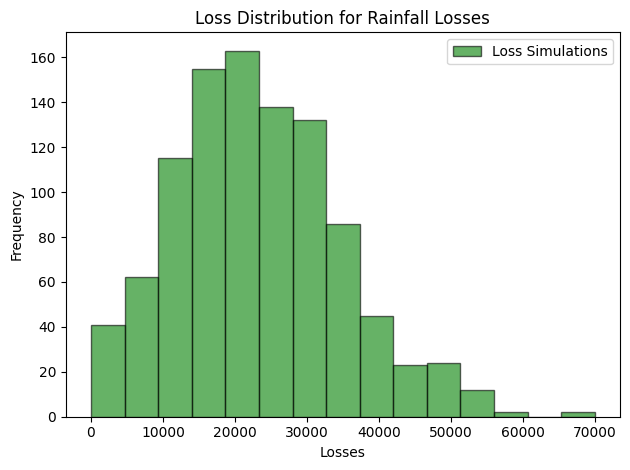

In [33]:
#Plot the histogram of distribution of Rainfall Losses
plt.hist(annual_loss, bins=15, alpha=0.6, color='g', label='Loss Simulations', edgecolor='black')
plt.legend()
plt.xlabel('Losses')
plt.ylabel('Frequency')
plt.title('Loss Distribution for Rainfall Losses')
plt.tight_layout()
plt.show()

The distirbution is slightly positively skewed like a Gamma Distribution. This makes sense since in many general insurance products, losses follow a positively skewed distribution like Gamma.

In [34]:
#Mean Loss (Pure Risk Premium)
print(f"The expected loss is: ${annual_loss.mean():.2f}")

The expected loss is: $23186.24


In [35]:
#Risk Measures
percentile_90 = np.percentile(annual_loss, 90)
percentile_95 = np.percentile(annual_loss, 95)
percentile_99 = np.percentile(annual_loss, 99)

print(f"The 90th percentile loss is ${percentile_90:.2f}.")
print(f"The 95th percentile loss is ${percentile_95:.2f}.")
print(f"The 99th percentile loss is ${percentile_99:.2f}.")

The 90th percentile loss is $37773.20.
The 95th percentile loss is $45096.95.
The 99th percentile loss is $52653.29.


In [36]:
#Payout Frequency
payout_frequency = (annual_loss > 0).mean()
print(f"Probability of at least one payout in a year: {payout_frequency:.1%}")

Probability of at least one payout in a year: 99.7%


The simulated expected annual loss is around $23,000 for a contract limit of $120,000. The relatively high expected loss reflects the frequency of extreme rainfall events generated by the stochastic rainfall model. 

The risk premium for this should therefore be around $23,000 for a year. The. actual insurance premium would add for expenses and profit loading along with underwriting considerations and market conditions.

The probabillity of loss in any one year is quite high (almost 100%). 

The loss estimates in this notebook should be interpreted with caution. The stochastic rainfall model exhibits heavier tails than historical data, as identified in notebook 02. This leads to more frequent trigger breaches in the simulated paths than would be expected historically, resulting in an upward bias in the pure risk premium. A more conservative model (such as a Bernoulli-Gamma compound specification) would likely produce lower and more realistic loss estimates.

In [39]:
#Sensitivity of annual losses to different trigger points
trigger_percentiles = [80, 85, 90, 95, 99]
results = []

for pct in trigger_percentiles:
    t = np.percentile(aggreagte_rainfall[' PRECIPITATION'], pct)
    m = np.percentile(aggreagte_rainfall[' PRECIPITATION'], 99)
    
    losses = np.zeros((stochastic_rain_path_notebook.number_of_paths, 12))
    for i in range(stochastic_rain_path_notebook.number_of_paths):
        for j in range(12):
            if monthly_aggregate_rainfall[i,j] < t:
                losses[i,j] = 0
            elif monthly_aggregate_rainfall[i,j] > m:
                losses[i,j] = 10000
            else:
                losses[i,j] = 10000 * (monthly_aggregate_rainfall[i,j] - t) / (m - t)
    
    annual = losses.sum(axis=1)
    results.append({
        'Trigger Percentile': f'{pct}th',
        'Trigger Value': round(t, 2),
        'Pure Risk Premium ($)': round(annual.mean(), 2),
        '90th Pct Loss ($)': round(np.percentile(annual, 90), 2),
        '99th Pct Loss ($)': round(np.percentile(annual, 99), 2),
        'Payout Frequency': f"{(annual > 0).mean():.1%}"
    })

sensitivity_df = pd.DataFrame(results)
display(sensitivity_df)

,Trigger Percentile,Trigger Value,Pure Risk Premium ($),90th Pct Loss ($),99th Pct Loss ($),Payout Frequency
0,80th,7.72,28472.46,43143.79,56872.88,99.9%
1,85th,8.79,26095.31,41150.11,55327.93,99.9%
2,90th,10.29,23186.24,37773.20,52653.29,99.7%
3,95th,12.48,19661.40,33808.35,48511.94,97.5%
4,99th,19.42,12160.00,30000.00,40000.00,72.8%


The results in this sensitivity analysis are consistent with what we expected. The simulated paths overestimate the rainfall and so there's a payout in almost each year. In reality, this may not be true and hence this is an important limitation of our analysis. We might have to revisit the methodology for simulating rainfall paths given the tails are very heavy. 

### End of Notebook